In [1]:
import numpy as np
import matplotlib.pyplot as plt
from public_tests import *
from utils import *

%matplotlib inline

In [2]:
X_train = np.array([[1,1,1],[1,0,1],[1,0,0],[1,0,0],[1,1,1],[0,1,1],[0,0,0],[1,0,1],[0,1,0],[1,0,0]])
y_train = np.array([1,1,0,0,1,0,0,1,1,0])

In [4]:
print("First few elements of X_train:\n", X_train[:5])
print("Type of y_train:", type(X_train))

First few elements of X_train:
 [[1 1 1]
 [1 0 1]
 [1 0 0]
 [1 0 0]
 [1 1 1]]
Type of y_train: <class 'numpy.ndarray'>


In [5]:
print("First few elements of y_train:", y_train[:5])
print("Type of y_train:",type(y_train))

First few elements of y_train: [1 1 0 0 1]
Type of y_train: <class 'numpy.ndarray'>


In [6]:
print('The shape of X_train is:', X_train.shape)
print('The shape of y_train is:', y_train.shape)
print('Number of training examples (m):', len(X_train))

The shape of X_train is: (10, 3)
The shape of y_train is: (10,)
Number of training examples (m): 10


<a name="4"></a>
## 4 - Decision Tree Refresher

In this practice lab, you will build a decision tree based on the dataset provided.

- Recall that the steps for building a decision tree are as follows:
    - Start with all examples at the root node
    - Calculate information gain for splitting on all possible features, and pick the one with the highest information gain
    - Split dataset according to the selected feature, and create left and right branches of the tree
    - Keep repeating splitting process until stopping criteria is met
  
  
- In this lab, you'll implement the following functions, which will let you split a node into left and right branches using the feature with the highest information gain
    - Calculate the entropy at a node 
    - Split the dataset at a node into left and right branches based on a given feature
    - Calculate the information gain from splitting on a given feature
    - Choose the feature that maximizes information gain
    
- We'll then use the helper functions you've implemented to build a decision tree by repeating the splitting process until the stopping criteria is met 
    - For this lab, the stopping criteria we've chosen is setting a maximum depth of 2

<a name="4"></a>
## 4 - Decision Tree Refresher

In this practice lab, you will build a decision tree based on the dataset provided.

- Recall that the steps for building a decision tree are as follows:
    - Start with all examples at the root node
    - Calculate information gain for splitting on all possible features, and pick the one with the highest information gain
    - Split dataset according to the selected feature, and create left and right branches of the tree
    - Keep repeating splitting process until stopping criteria is met
  
  
- In this lab, you'll implement the following functions, which will let you split a node into left and right branches using the feature with the highest information gain
    - Calculate the entropy at a node 
    - Split the dataset at a node into left and right branches based on a given feature
    - Calculate the information gain from splitting on a given feature
    - Choose the feature that maximizes information gain
    
- We'll then use the helper functions you've implemented to build a decision tree by repeating the splitting process until the stopping criteria is met 
    - For this lab, the stopping criteria we've chosen is setting a maximum depth of 2

In [8]:
def compute_entropy(y):
    entropy = 0
    if len(y) != 0:
        p1 = np.sum(y == 1) / len(y)
        if p1 == 0 or p1 == 1:
            return 0
        else:
            p0 = 1 - p1
            entropy = - p1 * np.log2(p1) - p0 * np.log2(p0)

    return entropy
        

In [9]:
# Compute entropy at the root node (i.e. with all examples)
# Since we have 5 edible and 5 non-edible mushrooms, the entropy should be 1"

print("Entropy at root node: ", compute_entropy(y_train)) 

# UNIT TESTS
compute_entropy_test(compute_entropy)

Entropy at root node:  1.0
 All tests passed. 


<a name="4.2"></a>
### 4.2  Split dataset

Next, you'll write a helper function called `split_dataset` that takes in the data at a node and a feature to split on and splits it into left and right branches. Later in the lab, you'll implement code to calculate how good the split is.

- The function takes in the training data, the list of indices of data points at that node, along with the feature to split on. 
- It splits the data and returns the subset of indices at the left and the right branch.
- For example, say we're starting at the root node (so `node_indices = [0,1,2,3,4,5,6,7,8,9]`), and we chose to split on feature `0`, which is whether or not the example has a brown cap. 
    - The output of the function is then, `left_indices = [0,1,2,3,4,7,9]` (data points with brown cap) and `right_indices = [5,6,8]` (data points without a brown cap)
    
    
|       |                                                    | Brown Cap | Tapering Stalk Shape | Solitary | Edible |
|-------|:--------------------------------------------------:|:---------:|:--------------------:|:--------:|:------:|
| 0     | <img src="images/0.png" alt="drawing" width="50"/> |     1     |           1          |     1    |    1   |
| 1     | <img src="images/1.png" alt="drawing" width="50"/> |     1     |           0          |     1    |    1   |
| 2     | <img src="images/2.png" alt="drawing" width="50"/> |     1     |           0          |     0    |    0   |
| 3     | <img src="images/3.png" alt="drawing" width="50"/> |     1     |           0          |     0    |    0   |
| 4     | <img src="images/4.png" alt="drawing" width="50"/> |     1     |           1          |     1    |    1   |
| 5     | <img src="images/5.png" alt="drawing" width="50"/> |     0     |           1          |     1    |    0   |
| 6     | <img src="images/6.png" alt="drawing" width="50"/> |     0     |           0          |     0    |    0   |
| 7     | <img src="images/7.png" alt="drawing" width="50"/> |     1     |           0          |     1    |    1   |
| 8     | <img src="images/8.png" alt="drawing" width="50"/> |     0     |           1          |     0    |    1   |
| 9     | <img src="images/9.png" alt="drawing" width="50"/> |     1     |           0          |     0    |    0   |
    
<a name="ex02"></a>
### Exercise 2

Please complete the `split_dataset()` function shown below

- For each index in `node_indices`
    - If the value of `X` at that index for that feature is `1`, add the index to `left_indices`
    - If the value of `X` at that index for that feature is `0`, add the index to `right_indices`

If you get stuck, you can check out the hints presented after the cell below to help you with the implementation.

In [10]:
def split_dataset(X, node_indices, feature):
    left_indices = []
    right_indices = []
    
    for i in node_indices:
        if X[i, feature] == 0:
            left_indices.append(i)
        else:
            right_indices.append(i)
    return left_indices, right_indices

CASE 1:
Left indices:  [5, 6, 8]
Right indices:  [0, 1, 2, 3, 4, 7, 9]


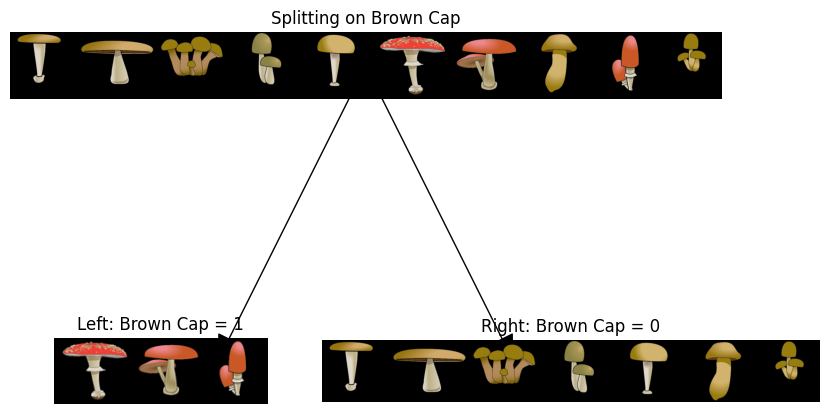


CASE 2:
Left indices:  [6, 8]
Right indices:  [0, 2, 4]


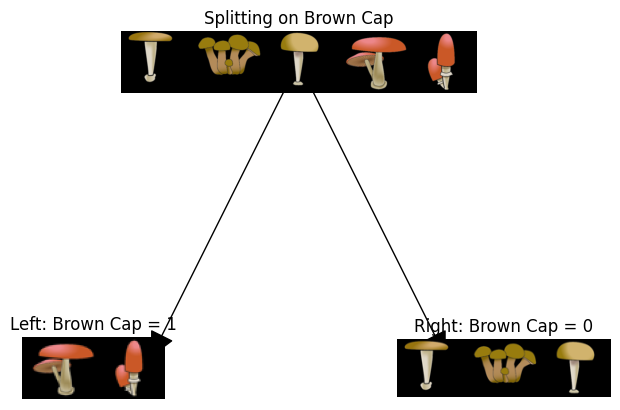

AssertionError: left must have 2 elements but got: 3

In [13]:
# Case 1

root_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# Feel free to play around with these variables
# The dataset only has three features, so this value can be 0 (Brown Cap), 1 (Tapering Stalk Shape) or 2 (Solitary)
feature = 0

left_indices, right_indices = split_dataset(X_train, root_indices, feature)

print("CASE 1:")
print("Left indices: ", left_indices)
print("Right indices: ", right_indices)

# Visualize the split 
generate_split_viz(root_indices, left_indices, right_indices, feature)

print()

# Case 2

root_indices_subset = [0, 2, 4, 6, 8]
left_indices, right_indices = split_dataset(X_train, root_indices_subset, feature)

print("CASE 2:")
print("Left indices: ", left_indices)
print("Right indices: ", right_indices)

# Visualize the split 
generate_split_viz(root_indices_subset, left_indices, right_indices, feature)

# UNIT TESTS    
split_dataset_test(split_dataset)

In [14]:
# UNQ_C3
# GRADED FUNCTION: compute_information_gain

def compute_information_gain(X, y, node_indices, feature):
    
    """
    Compute the information of splitting the node on a given feature
    
    Args:
        X (ndarray):            Data matrix of shape(n_samples, n_features)
        y (array like):         list or ndarray with n_samples containing the target variable
        node_indices (ndarray): List containing the active indices. I.e, the samples being considered in this step.
        feature (int):           Index of feature to split on
   
    Returns:
        cost (float):        Cost computed
    
    """    
    # Split dataset
    left_indices, right_indices = split_dataset(X, node_indices, feature)
    
    # Some useful variables
    X_node, y_node = X[node_indices], y[node_indices]
    X_left, y_left = X[left_indices], y[left_indices]
    X_right, y_right = X[right_indices], y[right_indices]
    
    # You need to return the following variables correctly
    information_gain = 0
    
    ### START CODE HERE ###
    node_entropy = compute_entropy(y_node)
    left_entropy = compute_entropy(y_left)
    right_entropy = compute_entropy(y_right)
    
    w_left = len(X_left) / len(X_node)
    w_right = len(X_right) / len(X_node)
    
    weighted_gain = w_left * left_entropy + w_right * right_entropy
    
    information_gain = node_entropy - weighted_gain
    
    
    
    
    
    
    
    
    
    
    
    
    ### END CODE HERE ###  
    
    return information_gain

In [15]:
info_gain0 = compute_information_gain(X_train, y_train, root_indices, feature=0)
print("Information Gain from splitting the root on brown cap: ", info_gain0)

info_gain1 = compute_information_gain(X_train, y_train, root_indices, feature=1)
print("Information Gain from splitting the root on tapering stalk shape: ", info_gain1)

info_gain2 = compute_information_gain(X_train, y_train, root_indices, feature=2)
print("Information Gain from splitting the root on solitary: ", info_gain2)

# UNIT TESTS
compute_information_gain_test(compute_information_gain)

Information Gain from splitting the root on brown cap:  0.034851554559677034
Information Gain from splitting the root on tapering stalk shape:  0.12451124978365313
Information Gain from splitting the root on solitary:  0.2780719051126377
 All tests passed.


In [16]:
# UNQ_C4
# GRADED FUNCTION: get_best_split

def get_best_split(X, y, node_indices):   
    """
    Returns the optimal feature and threshold value
    to split the node data 
    
    Args:
        X (ndarray):            Data matrix of shape(n_samples, n_features)
        y (array like):         list or ndarray with n_samples containing the target variable
        node_indices (ndarray): List containing the active indices. I.e, the samples being considered in this step.

    Returns:
        best_feature (int):     The index of the best feature to split
    """    
    
    # Some useful variables
    num_features = X.shape[1]
    
    # You need to return the following variables correctly
    best_feature = -1
    
    ### START CODE HERE ###
    max_info_gain = 0
    for feature in range(num_features):
        info_gain = compute_information_gain(X, y, node_indices, feature)
        
        if info_gain > max_info_gain:
            max_info_gain = info_gain
            best_feature = feature
    
    
        
        
            
            
    ### END CODE HERE ##    
   
    return best_feature

In [17]:
best_feature = get_best_split(X_train, y_train, root_indices)
print("Best feature to split on: %d" % best_feature)

# UNIT TESTS
get_best_split_test(get_best_split)

Best feature to split on: 2
 All tests passed.


In [18]:
# Not graded
tree = []

def build_tree_recursive(X, y, node_indices, branch_name, max_depth, current_depth):
    """
    Build a tree using the recursive algorithm that split the dataset into 2 subgroups at each node.
    This function just prints the tree.
    
    Args:
        X (ndarray):            Data matrix of shape(n_samples, n_features)
        y (array like):         list or ndarray with n_samples containing the target variable
        node_indices (ndarray): List containing the active indices. I.e, the samples being considered in this step.
        branch_name (string):   Name of the branch. ['Root', 'Left', 'Right']
        max_depth (int):        Max depth of the resulting tree. 
        current_depth (int):    Current depth. Parameter used during recursive call.
   
    """ 

    # Maximum depth reached - stop splitting
    if current_depth == max_depth:
        formatting = " "*current_depth + "-"*current_depth
        print(formatting, "%s leaf node with indices" % branch_name, node_indices)
        return
   
    # Otherwise, get best split and split the data
    # Get the best feature and threshold at this node
    best_feature = get_best_split(X, y, node_indices) 
    
    formatting = "-"*current_depth
    print("%s Depth %d, %s: Split on feature: %d" % (formatting, current_depth, branch_name, best_feature))
    
    # Split the dataset at the best feature
    left_indices, right_indices = split_dataset(X, node_indices, best_feature)
    tree.append((left_indices, right_indices, best_feature))
    
    # continue splitting the left and the right child. Increment current depth
    build_tree_recursive(X, y, left_indices, "Left", max_depth, current_depth+1)
    build_tree_recursive(X, y, right_indices, "Right", max_depth, current_depth+1)

 Depth 0, Root: Split on feature: 2
- Depth 1, Left: Split on feature: 1
  -- Left leaf node with indices [2, 3, 6, 9]
  -- Right leaf node with indices [8]
- Depth 1, Right: Split on feature: 0
  -- Left leaf node with indices [5]
  -- Right leaf node with indices [0, 1, 4, 7]


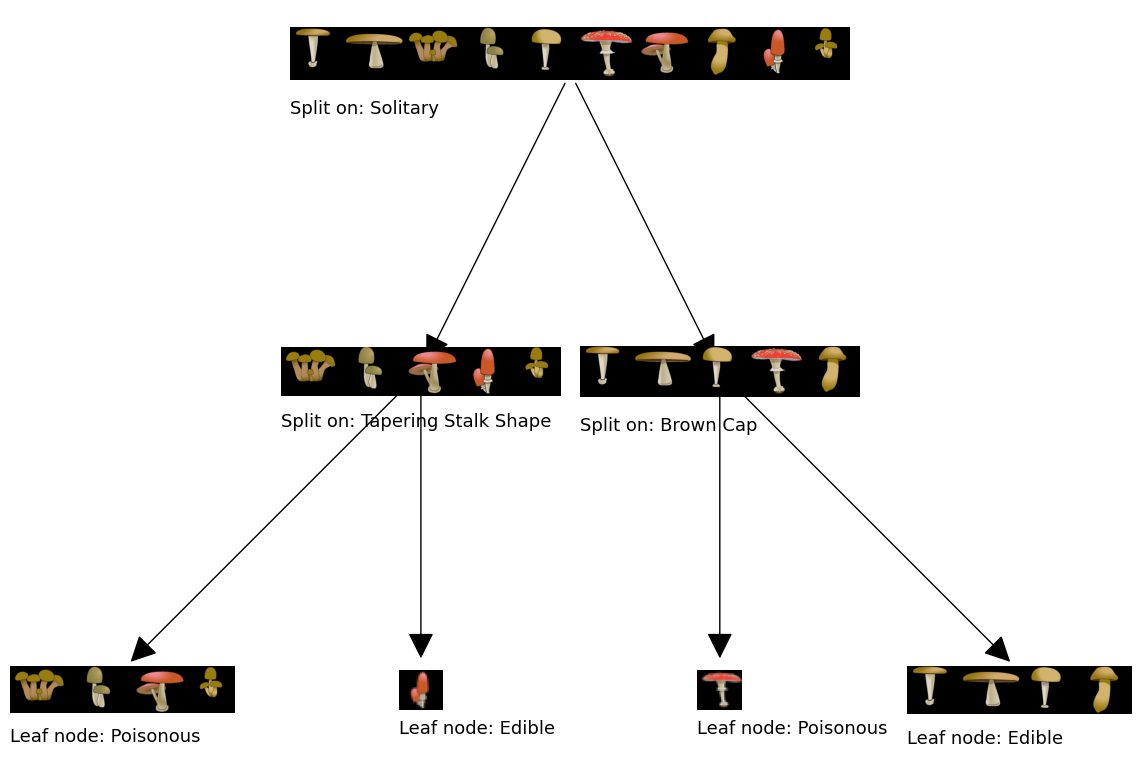

In [19]:
build_tree_recursive(X_train, y_train, root_indices, "Root", max_depth=2, current_depth=0)
generate_tree_viz(root_indices, y_train, tree)